# Using Text embeding 
### for featurizing our text and comparing with NFM I chose Word2Vec

In [1]:
import pandas as pd
from gensim.models import Word2Vec
import numpy as np

In [2]:
df = pd.read_csv('document_df.csv')
df

,text,cleaned_text
0,Our 24-year-old non-smoking male patient prese...,male patient repeated hemoptysis concomitant r...
1,A 25-year-old female patient had noticed left-...,female patient visual loss amenorrhea right he...
2,A 69-year-old male diabetic patient was admitt...,male diabetic patient acute ventricular lv fai...
3,Our patient was a 7-year-old Italian boy born ...,patient italian boy uneventful gestation norma...
4,A 53-year-old man came to our hospital with si...,man hospital sign symptom acute heart failure ...
...,...,...
196,A 65-year-old woman reported persistent back p...,woman persistent pain month symptom severe pos...
197,A 65-year-old man was admitted to the China-Ja...,man chinajapan friendship hospital chief compl...
198,The institutional review board (Chengdu Milita...,institutional review board chengdu military ge...
199,A 65-year-old man with a 45-year history of ci...,man history cigarette smoking hospital diagnos...


In [3]:
# Tokenize and preprocess documents
documents = df["cleaned_text"].tolist()  # Preprocessed text
tokenized_docs = [doc.split() for doc in documents]  # Tokenize each document
tokenized_docs

[['male',
  'patient',
  'repeated',
  'hemoptysis',
  'concomitant',
  'right',
  'thoracic',
  'pain',
  'holiday',
  'home',
  'country',
  'cuban',
  'patient',
  'cold',
  'fever',
  'strong',
  'cough',
  'strong',
  'dry',
  'cough',
  'recovery',
  'cold',
  'patient',
  'loss',
  'weight',
  'initial',
  'ct',
  'scan',
  'thorax',
  'cm',
  'solid',
  'mass',
  'paravertebral',
  'right',
  'low',
  'thorax',
  'sign',
  'metastasis',
  'bronchoscopy',
  'figure',
  'biopsy',
  'mass',
  'low',
  'right',
  'bronchus',
  'evidence',
  'granular',
  'cell',
  'abrikossoff',
  'tumor',
  'bronchial',
  'lavage',
  'negative',
  'malignant',
  'cell',
  'patient',
  'surgical',
  'intervention',
  'discharge',
  'spontaneous',
  'hemothorax',
  'patient',
  'hemothorax',
  'malignant',
  'cell',
  'cytological',
  'examination',
  'liquid',
  'uneventful',
  'course',
  'decreasing',
  'hematoma',
  'tumor',
  'low',
  'right',
  'lobectomy',
  'month',
  'initial',
  'admission

In [4]:
# for training the Word2Vec we used the tokenized words from preprocessing text to remove noise
# to avoid overfitting I used vector_size of 100
# the windows is maximum distance between the current word and predicted words within a sentence and window = 5 
# Captures broader semantic relationships
# the min_count ignores words that appear less than min_count times in the dataset.
# workers is number of threads for parallization

In [5]:
# Train Word2Vec model
print("Training Word2Vec model...")
word2vec_model = Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=1, workers=4, seed=42)

Training Word2Vec model...


In [6]:
#Compute document vectors by averaging word vectors
def compute_doc_vector(doc, model):
    """Generate a document vector by averaging the word embeddings."""
    word_vectors = [model.wv[word] for word in doc if word in model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(model.vector_size)

In [7]:
from sklearn.cluster import KMeans
# Create document vectors
doc_vectors = np.array([compute_doc_vector(doc, word2vec_model) for doc in tokenized_docs])

# Apply K-Means clustering
num_clusters = 5  # Define the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
doc_clusters = kmeans.fit_predict(doc_vectors)

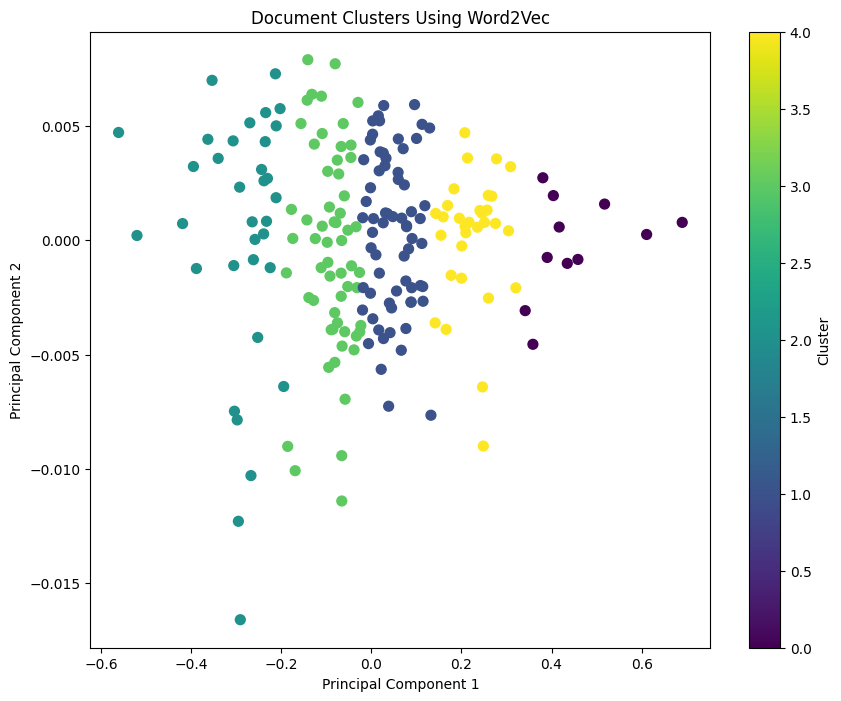

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#Visualize clusters in 2D using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(doc_vectors)

# Scatter plot of clusters
plt.figure(figsize=(10, 8))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=doc_clusters, cmap='viridis', s=50)
plt.colorbar(label="Cluster")
plt.title("Document Clusters Using Word2Vec")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [9]:
# comapre to TF-IDF we can see better separation. we don't see the V-shape that we saw previously and we don't see 
# much of the overlapping in coordinate (0,0). from left to right we see vector value of documents of topic 3 then topic 1
# then topic 2 then topic 0 and lastly topic 4